In [1]:
%load_ext autoreload
%autoreload 2
import arcworld.generator as generator 
import time
import sys 
from arcworld.general_utils import plot_task, plot_grid

# Generating by randomly sampling transformations

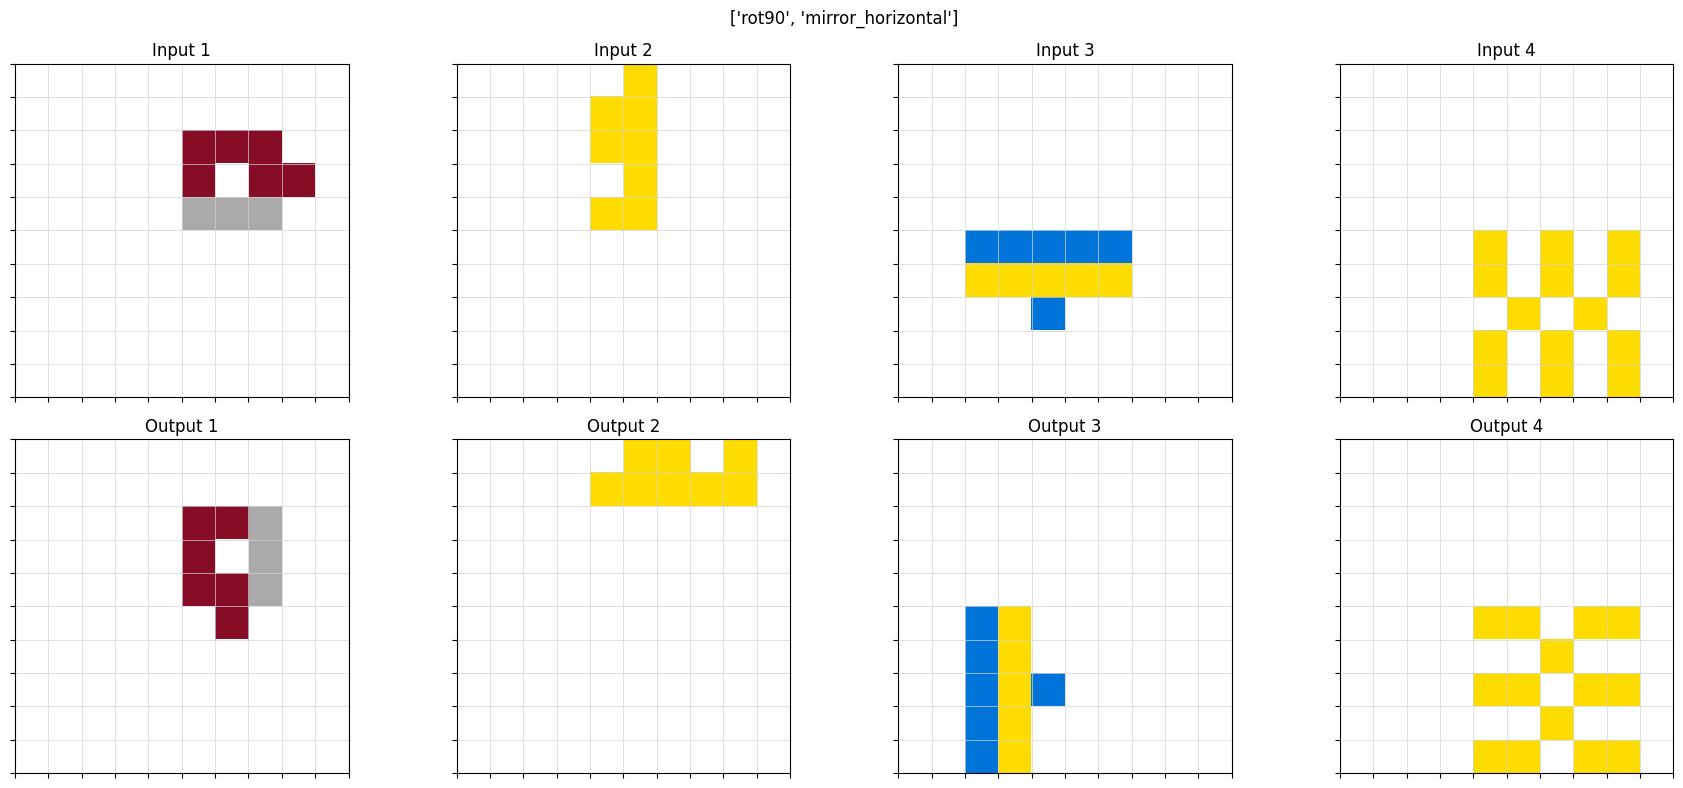

In [8]:
# At each run, the generator will create a new task with a different combination of transformations, as described in the config file.

config = {
    "min_n_shapes_per_grid": 1,
    "max_n_shapes_per_grid": 1,
    "n_examples": 4,
    "min_grid_size": 10,
    "max_grid_size": 10,
    "allowed_combinations": [["rot90", "mirror_horizontal"], ["mirror_horizontal", "rot90"]],
    "allowed_transformations": None,
    "min_transformation_depth": None,
    "max_transformation_depth": None,
    "shape_compulsory_conditionals": ["is_shape_less_than_6_rows", 
                                      "is_shape_less_than_6_cols"],
}

gen = generator.Generator(config, debug_mode=True) # Initialize the generator with the config
task = gen.generate_single_task() # Generate a single task
plot_task(task)

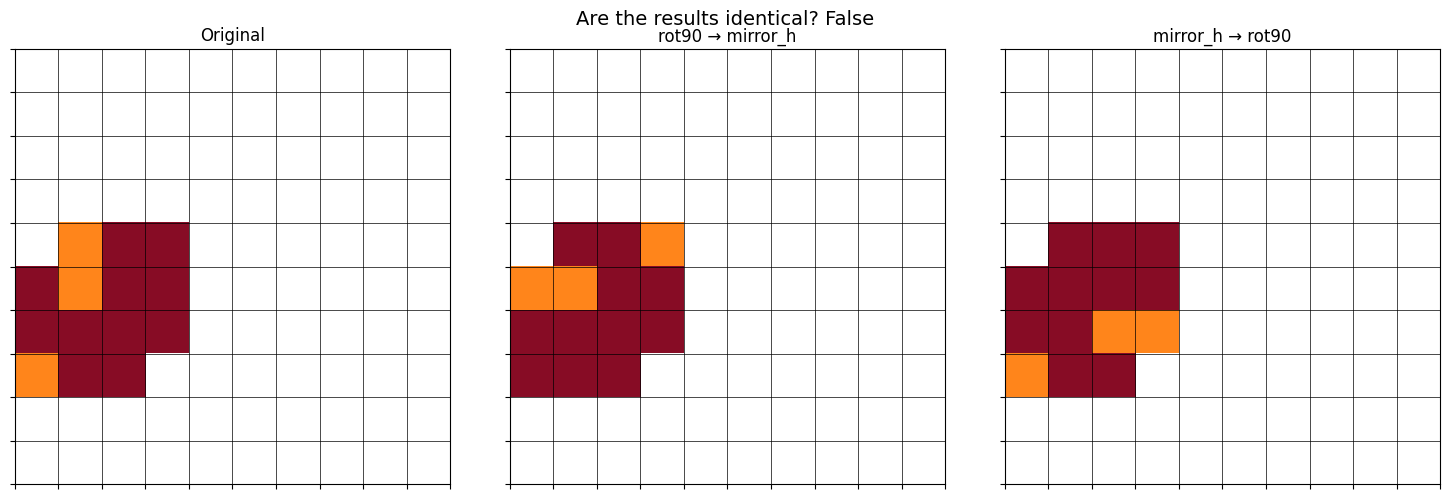

In [7]:
from arcworld.config import DatasetConfig
from arcworld.transformations.shape_transformations import transformations_dict
import matplotlib.pyplot as plt

# Config: 1 shape, fixed 10x10 grid
config = DatasetConfig(
    min_n_shapes_per_grid=1,
    max_n_shapes_per_grid=1,
    n_examples=1,
    min_grid_size=10,
    max_grid_size=10,
    allowed_combinations=[["rot90"]],  # dummy, we apply manually
    shape_compulsory_conditionals=["is_shape_less_than_6_rows", "is_shape_less_than_6_cols"],
)

gen = generator.Generator(config, debug_mode=True)

# Sample a shape and place it on a grid
compatible_rows = gen.get_compatible_shape_rows(
    shape_conditionals_to_satisfy=config.shape_compulsory_conditionals,
    shape_conditionals_not_to_satisfy=[],
)
input_grid, shapes = gen.set_up_initial_grid(compatible_rows)

rot90 = transformations_dict["rot90"]
mirror_h = transformations_dict["mirror_horizontal"]

# Order A: rot90 then mirror_horizontal
from arcworld.general_utils import position_shape_in_world
import numpy as np

def apply_and_build_grid(shapes, transforms, grid_shape):
    out = np.zeros(grid_shape)
    for s in shapes:
        t_shape = s
        for t in transforms:
            t_shape = t(t_shape)
        out = position_shape_in_world(out, t_shape)
    return out

grid_A = apply_and_build_grid(shapes, [rot90, mirror_h], input_grid.shape)
grid_B = apply_and_build_grid(shapes, [mirror_h, rot90], input_grid.shape)

# Plot all three
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Original", "rot90 → mirror_h", "mirror_h → rot90"]
grids = [input_grid, grid_A, grid_B]

from arcworld.constants import COLORMAP, NORM

for ax, grid, title in zip(axs, grids, titles):
    ax.imshow(grid, cmap=COLORMAP, norm=NORM)
    ax.grid(True, which='both', color='black', linewidth=0.5)
    ax.set_yticks([x - 0.5 for x in range(1 + grid.shape[0])])
    ax.set_xticks([x - 0.5 for x in range(1 + grid.shape[1])])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(title)

are_equal = np.array_equal(grid_A, grid_B)
fig.suptitle(f"Are the results identical? {are_equal}", fontsize=14)
plt.tight_layout()
plt.show()

# Generating by sampling from list of possible combinations

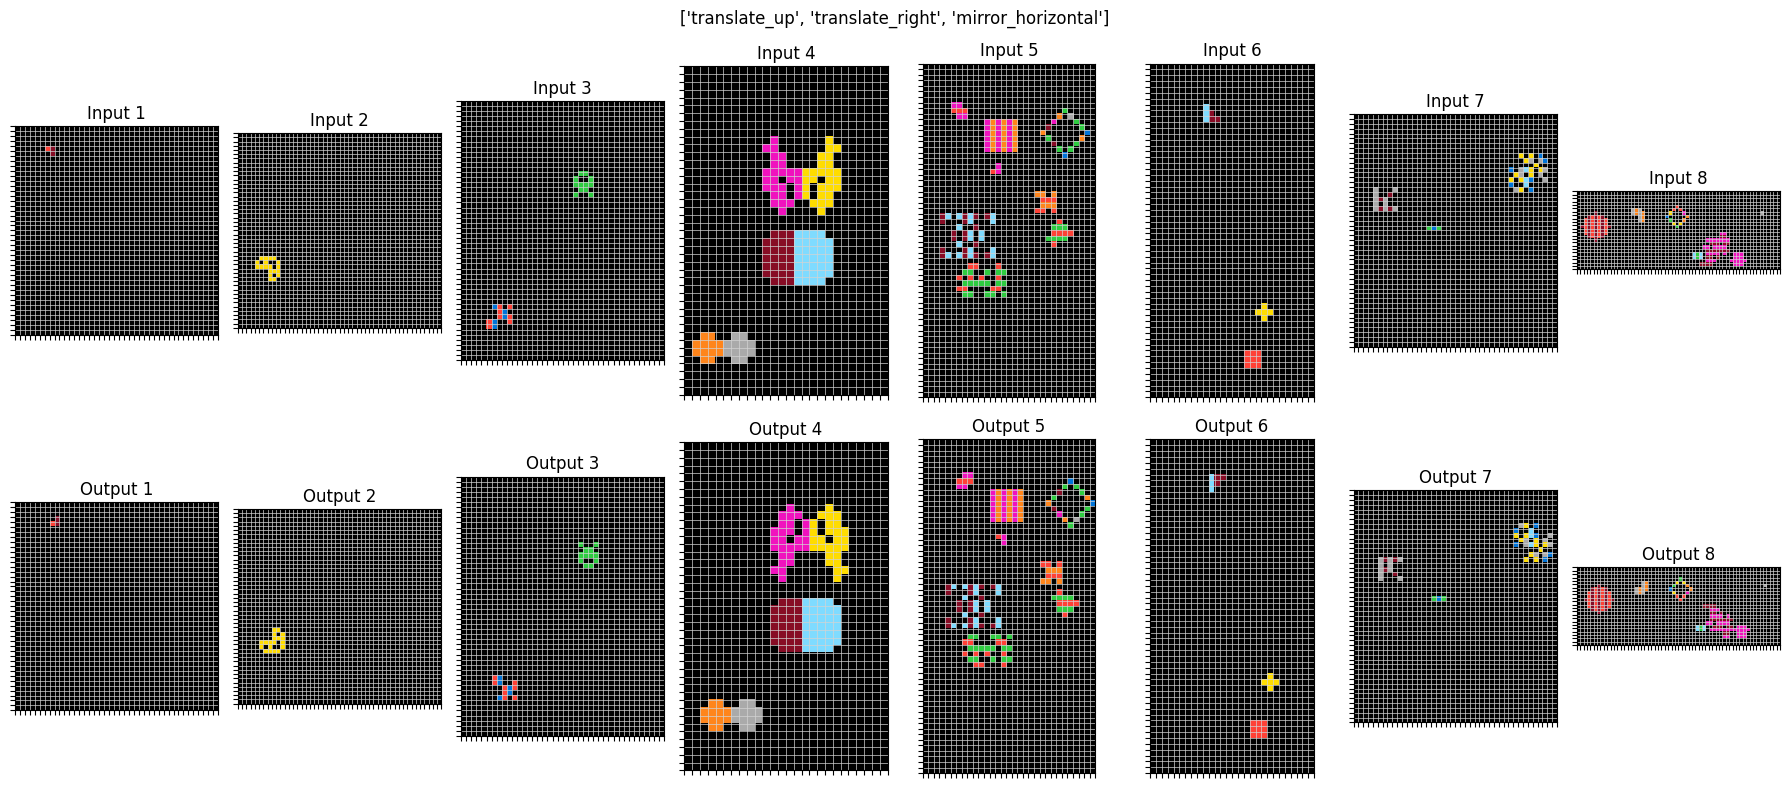

In [ ]:
# At each run, the generator will create a new task with a different combination of transformations, as described in the config file.
config = {
    "min_n_shapes_per_grid": 1,
    "max_n_shapes_per_grid": 8,
    "n_examples": 8,
    "min_grid_size": 20,
    "max_grid_size": 60,
    "allowed_combinations": [["translate_up", "translate_right", "mirror_horizontal"], 
                             ["translate_down", "translate_left", "mirror_vertical"],
                             ["mirror_horizontal"]],
    "allowed_transformations": None,
    "min_transformation_depth": None,
    "max_transformation_depth": None,
    "shape_compulsory_conditionals": ["is_shape_less_than_11_rows", 
                                      "is_shape_less_than_11_cols"]
                                    
}

gen = generator.Generator(config, debug_mode=True) # Initialize the generator with the config
task = gen.generate_single_task() # Generate a single task
plot_task(task)